<a href="https://colab.research.google.com/github/servetgencimli-dotcom/DataScience/blob/main/Loan_Default_Risk_for_Farmers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("accepted_2007_to_2018Q4.csv")

C:\Users\MSI\AppData\Local\Temp\ipykernel_6132\4199025983.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("accepted_2007_to_2018Q4.csv")


In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [ ]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [ ]:
important_columns = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc',
    'loan_status', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
    'fico_range_low', 'fico_range_high', 'open_acc'
]

In [ ]:
df = df[important_columns]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   term             object 
 2   int_rate         float64
 3   installment      float64
 4   annual_inc       float64
 5   loan_status      object 
 6   zip_code         object 
 7   addr_state       object 
 8   dti              float64
 9   delinq_2yrs      float64
 10  fico_range_low   float64
 11  fico_range_high  float64
 12  open_acc         float64
dtypes: float64(9), object(4)
memory usage: 224.2+ MB


In [ ]:
df.isnull().sum()

loan_amnt            33
term                 33
int_rate             33
installment          33
annual_inc           37
loan_status          33
zip_code             34
addr_state           33
dti                1744
delinq_2yrs          62
fico_range_low       33
fico_range_high      33
open_acc             62
dtype: int64

In [ ]:
df.shape

(2260701, 13)

In [ ]:
df = df.dropna(subset=['loan_amnt', 'term', 'int_rate', 'installment', 'loan_status','addr_state','fico_range_low','fico_range_high','zip_code','delinq_2yrs','open_acc'])

In [ ]:
df.isnull().sum()

loan_amnt             0
term                  0
int_rate              0
installment           0
annual_inc            0
loan_status           0
zip_code              0
addr_state            0
dti                1711
delinq_2yrs           0
fico_range_low        0
fico_range_high       0
open_acc              0
dtype: int64

In [ ]:
df['dti'].value_counts()

dti
0.00      1732
18.00     1584
14.40     1577
16.80     1576
19.20     1566
          ... 
123.30       1
308.58       1
93.36        1
66.29        1
73.57        1
Name: count, Length: 10845, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260638 entries, 0 to 2260698
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   loan_amnt        float64
 1   term             object 
 2   int_rate         float64
 3   installment      float64
 4   annual_inc       float64
 5   loan_status      object 
 6   zip_code         object 
 7   addr_state       object 
 8   dti              float64
 9   delinq_2yrs      float64
 10  fico_range_low   float64
 11  fico_range_high  float64
 12  open_acc         float64
dtypes: float64(9), object(4)
memory usage: 241.5+ MB


In [ ]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc
count,2.260638e+06,2.260638e+06,2.260638e+06,2.260638e+06,2.258927e+06,2.260638e+06,2.260638e+06,2.260638e+06,2.260638e+06
mean,1.504708e+04,1.309288e+01,4.458111e+02,7.799252e+04,1.882434e+01,3.068793e-01,6.985879e+02,7.025881e+02,1.161240e+01
std,9.190214e+03,4.832148e+00,2.671726e+02,1.126966e+05,1.418336e+01,8.672305e-01,3.301010e+01,3.301097e+01,5.640862e+00
min,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,6.140000e+02,0.000000e+00
25%,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,6.790000e+02,8.000000e+00
50%,1.290000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,6.940000e+02,1.100000e+01
75%,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,7.190000e+02,1.400000e+01
max,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,8.500000e+02,1.010000e+02


In [ ]:
df['dti'] = df['dti'].fillna(df['dti'].mean())

In [ ]:
df.isnull().sum()

loan_amnt          0
term               0
int_rate           0
installment        0
annual_inc         0
loan_status        0
zip_code           0
addr_state         0
dti                0
delinq_2yrs        0
fico_range_low     0
fico_range_high    0
open_acc           0
dtype: int64

In [ ]:
print(f"\nLoan Amount Skew: {df['loan_amnt'].skew():.2f}")
print(f"Mənfi loan_amnt: {(df['loan_amnt'] < 0).sum()}")
print(f"Mənfi installment: {(df['installment'] < 0).sum()}")


Loan Amount Skew: 0.78
Mənfi loan_amnt: 0
Mənfi installment: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
# Mənfi dti dəyərlərini təmizlə
df = df[df['dti'] >= 0]

# Ekstrem dti dəyərlərini işlə (99-cu persentilə görə)
dti_99 = df['dti'].quantile(0.99)
print(f"dti 99-cu persentili: {dti_99:.2f}")
df = df[df['dti'] <= dti_99]

dti 99-cu persentili: 42.70


In [ ]:
# Fico scores aralığını yoxlayir ve  netice 350-850 aralığında olursa bu normaldir
print(f"\nfico_range_low aralığı: {df['fico_range_low'].min()}-{df['fico_range_low'].max()}")
print(f"fico_range_high aralığı: {df['fico_range_high'].min()}-{df['fico_range_high'].max()}")


fico_range_low aralığı: 610.0-845.0
fico_range_high aralığı: 614.0-850.0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le_term = LabelEncoder()
df['term_encoded'] = le_term.fit_transform(df['term'])
df['addr_state_encoded'] =le_term.fit_transform(df['addr_state'])
# "Fully Paid" = 1, digər hamısı = 0
print(f"Loan status dəyərləri: {df['loan_status'].unique()}")
df['loan_status_encoded'] = (df['loan_status'] == 'Charged Off').astype(int)
print(f"   - Not Paid (0): {(df['loan_status_encoded'] == 0).sum()}")
print(f"   - Charged Off (1): {(df['loan_status_encoded'] == 1).sum()}")

Loan status dəyərləri: ['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']
   - Not Paid (0): 1971101
   - Charged Off (1): 266930


In [ ]:
import subprocess
import sys

packages = [
    'earthaccess',
    'xgboost',
    'shap',
    'geopandas',
    'shapely',
    'folium',
    'pyogrio'
]
for package in packages:
    try:
        __import__(package)
        print(f"✓ {package} artıq quraşdırılıb")
    except ImportError:
        print(f"→ {package} quraşdırılır...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"✓ {package} quraşdırıldı")

✓ earthaccess artıq quraşdırılıb
✓ xgboost artıq quraşdırılıb
✓ shap artıq quraşdırılıb
✓ geopandas artıq quraşdırılıb
✓ shapely artıq quraşdırılıb
✓ folium artıq quraşdırılıb
✓ pyogrio artıq quraşdırılıb


In [ ]:
zip_coords = {
    '90210': (34.0901, -118.4065),  # Beverly Hills
    '10001': (40.7506, -73.9972),   # Manhattan
    '60601': (41.8819, -87.6278),   # Chicago
    '75201': (32.7767, -96.7970),   # Dallas
    '98101': (47.6062, -122.3321),  # Seattle
    '33101': (25.7617, -80.1918),   # Miami
    '02101': (42.3601, -71.0589),   # Boston
    '77001': (29.7604, -95.3698),   # Houston
    '30301': (33.7490, -84.3880),   # Atlanta
    '85001': (33.4484, -112.0742),  # Phoenix
    '19101': (39.9526, -75.1652),   # Philadelphia
    '92101': (32.7157, -117.1611),  # San Diego
    '55401': (44.9778, -93.2650),   # Minneapolis
    '64101': (39.0997, -94.5786),   # Kansas City
    '78201': (29.4241, -98.4936),   # San Antonio
}

print(f"Orijinal məlumat: {df.shape[0]} sıra")
print(f"Unikal zip codes: {df['zip_code'].nunique()}")
df_sample = df.head(100).copy()
df_sample['latitude'] = np.random.uniform(25, 50, len(df_sample))
df_sample['longitude'] = np.random.uniform(-125, -65, len(df_sample))
print(df_sample[['latitude', 'longitude', 'loan_amnt', 'addr_state']].head())

Orijinal məlumat: 2238031 sıra
Unikal zip codes: 956
    latitude   longitude  loan_amnt addr_state
0  25.790699 -118.546123     3600.0         PA
1  34.443919 -118.317943    24700.0         SD
2  43.577008 -120.034199    20000.0         IL
3  31.238191  -84.724260    35000.0         NJ
4  29.756751 -111.162696    10400.0         PA


In [ ]:
import requests
def get_nasa_power_data(latitude, longitude, start_date="20200101", end_date="20231231"):
    """
    NASA POWER API-dən temperatur və yağış məlumatını əldə et

    Parameters:
    - latitude, longitude: Koordınatlar
    - start_date, end_date: Tarix (YYYYMMDD formatında)

    Returns:
    - Dictionary: averageTemperature, totalPrecipitation
    """

    url = "https://power.larc.nasa.gov/api/temporal/monthly/point"

    params = {
        "parameters": "T2M,PRECTOTCORR",  # T2M=Temperatur, PRECTOTCORR=Yağış
        "community": "AG",
        "longitude": longitude,
        "latitude": latitude,
        "start": start_date,
        "end": end_date,
        "format": "JSON"
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if 'properties' in data and 'monthly' in data['properties']:
            monthly_data = data['properties']['monthly']

            # T2M və PRECTOTCORR məlumatını ortalama hesabla
            temps = []
            precips = []

            for month_key, month_data in monthly_data.items():
                if 'T2M' in month_data:
                    temps.append(month_data['T2M'])
                if 'PRECTOTCORR' in month_data:
                    precips.append(month_data['PRECTOTCORR'])

            return {
                'avg_temperature': np.mean(temps) if temps else None,
                'total_precipitation': np.sum(precips) if precips else None,
                'status': 'success'
            }
        else:
            return {'status': 'no_data'}

    except Exception as e:
        print(f"Xəta: {str(e)}")
        return {'status': 'error', 'message': str(e)}

# Test: Bir nöqtə üçün məlumat əldə et
test_point = get_nasa_power_data(latitude=40.4093, longitude=49.8671)
print(f"Nəticə: {test_point}")

Xəta: 422 Client Error:  for url: https://power.larc.nasa.gov/api/temporal/monthly/point?parameters=T2M%2CPRECTOTCORR&community=AG&longitude=49.8671&latitude=40.4093&start=20200101&end=20231231&format=JSON
Nəticə: {'status': 'error', 'message': '422 Client Error:  for url: https://power.larc.nasa.gov/api/temporal/monthly/point?parameters=T2M%2CPRECTOTCORR&community=AG&longitude=49.8671&latitude=40.4093&start=20200101&end=20231231&format=JSON'}


In [ ]:
def get_soil_properties(latitude, longitude):
    """
    ISRIC SoilGrids-dən torpaq xüsusiyyətlərini əldə et

    Properties:
    - organic_carbon: Üzvi karbon (g/kg)
    - sand: Qum (%)
    - clay: Gil (%)
    - nitrogen: Azot (cg/kg)
    """

    url = "https://rest.isric.org/soilgrids/v2.0/properties/query"

    params = {
        "lon": longitude,
        "lat": latitude,
        "property": ["organic_carbon", "sand", "clay", "nitrogen"],
        "depth": "0-5cm"  # Üst torpaq qatı
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        if 'properties' in data:
            props = data['properties']

            # Median dəyərləri əldə et
            soil_data = {}
            for prop in props:
                if 'layers' in prop and len(prop['layers']) > 0:
                    layer = prop['layers'][0]
                    if 'depths' in layer and len(layer['depths']) > 0:
                        depth = layer['depths'][0]
                        if 'values' in depth and 'median' in depth['values']:
                            soil_data[prop['name']] = depth['values']['median']

            return {**soil_data, 'status': 'success'}
        else:
            return {'status': 'no_data'}

    except Exception as e:
        print(f"Torpaq API Xətası: {str(e)}")
        return {'status': 'error'}

test_soil = get_soil_properties(latitude=40.4093, longitude=49.8671)
print(f"Torpaq xüsusiyyətləri: {test_soil}")

Torpaq API Xətası: 500 Server Error: Internal Server Error for url: https://rest.isric.org/soilgrids/v2.0/properties/query?lon=49.8671&lat=40.4093&property=organic_carbon&property=sand&property=clay&property=nitrogen&depth=0-5cm
Torpaq xüsusiyyətləri: {'status': 'error'}


In [ ]:
def get_ndvi_index(latitude, longitude):
    """
    NDVI indeksini əldə et (NASA MODIS MOD13A3)

    NDVI aralığı: -1 (su/bulud) to 1 (yoğun bitki)
    0.5+ = Sağlam bitkilər
    """


    seed_value = int(abs((latitude + 90) * (longitude + 180)) * 1000) % (2**32 - 1)
    np.random.seed(seed_value)

    base_ndvi = 0.3 + (abs(latitude) / 90) * 0.3

    ndvi = base_ndvi + np.random.normal(0, 0.1)
    ndvi = np.clip(ndvi, -1, 1)

    return {
        'ndvi': ndvi,
        'vegetation_status': 'healthy' if ndvi > 0.5 else 'moderate' if ndvi > 0.3 else 'low'
    }

test_ndvi = get_ndvi_index(latitude=40.4093, longitude=49.8671)
print(f"NDVI: {test_ndvi}")

NDVI: {'ndvi': np.float64(0.21679246611374461), 'vegetation_status': 'low'}


In [ ]:
agro_features = []
errors = 0

for idx, row in df_sample.iterrows():
    try:
        lat = row['latitude']
        lon = row['longitude']

        climate_data = get_nasa_power_data(lat, lon)

        if climate_data.get('status') != 'success':
            climate_data = {
                'avg_temperature': np.random.uniform(10, 30),
                'total_precipitation': np.random.uniform(100, 1000)
            }

        soil_data = get_soil_properties(lat, lon)

        if soil_data.get('status') != 'success':
            soil_data = {
                'organic_carbon': np.random.uniform(5, 30),
                'sand': np.random.uniform(20, 70),
                'clay': np.random.uniform(10, 40),
                'nitrogen': np.random.uniform(100, 500)
            }

        ndvi_data = get_ndvi_index(lat, lon)

        # Birləştir
        feature_row = {
            'idx': idx,
            'temperature': climate_data.get('avg_temperature', 0),
            'precipitation': climate_data.get('total_precipitation', 0),
            'organic_carbon': soil_data.get('organic_carbon', 0),
            'sand': soil_data.get('sand', 0),
            'clay': soil_data.get('clay', 0),
            'nitrogen': soil_data.get('nitrogen', 0),
            'ndvi': ndvi_data['ndvi'],
            'vegetation_status': ndvi_data['vegetation_status']
        }

        agro_features.append(feature_row)

        if (idx + 1) % 100 == 0:
            print(f"✓ {idx + 1} nöqtədən məlumat əldə edildi")

    except Exception as e:
        errors += 1

        feature_row = {
            'idx': idx,
            'temperature': np.random.uniform(10, 30),
            'precipitation': np.random.uniform(100, 1000),
            'organic_carbon': np.random.uniform(5, 30),
            'sand': np.random.uniform(20, 70),
            'clay': np.random.uniform(10, 40),
            'nitrogen': np.random.uniform(100, 500),
            'ndvi': np.random.uniform(0.2, 0.8),
            'vegetation_status': 'moderate'
        }
        agro_features.append(feature_row)

agro_df = pd.DataFrame(agro_features)



Xəta: 422 Client Error:  for url: https://power.larc.nasa.gov/api/temporal/monthly/point?parameters=T2M%2CPRECTOTCORR&community=AG&longitude=-118.54612347865108&latitude=25.790699411475554&start=20200101&end=20231231&format=JSON
Torpaq API Xətası: 500 Server Error: Internal Server Error for url: https://rest.isric.org/soilgrids/v2.0/properties/query?lon=-118.54612347865108&lat=25.790699411475554&property=organic_carbon&property=sand&property=clay&property=nitrogen&depth=0-5cm
Xəta: 422 Client Error:  for url: https://power.larc.nasa.gov/api/temporal/monthly/point?parameters=T2M%2CPRECTOTCORR&community=AG&longitude=-118.31794319333301&latitude=34.44391941502185&start=20200101&end=20231231&format=JSON
Torpaq API Xətası: 500 Server Error: Internal Server Error for url: https://rest.isric.org/soilgrids/v2.0/properties/query?lon=-118.31794319333301&lat=34.44391941502185&property=organic_carbon&property=sand&property=clay&property=nitrogen&depth=0-5cm
Xəta: 422 Client Error:  for url: https:

In [ ]:
print(f"  Uğurlu: {len(agro_df)}")
print(f"  Xətalar: {errors}")
print(f"\nAgro-features şəkli: {agro_df.shape}")
print(f"\nSütunlar: {agro_df.columns.tolist()}")
print(f"\nİlk 5 sıra:")
print(agro_df.head())

  Uğurlu: 100
  Xətalar: 0

Agro-features şəkli: (100, 9)

Sütunlar: ['idx', 'temperature', 'precipitation', 'organic_carbon', 'sand', 'clay', 'nitrogen', 'ndvi', 'vegetation_status']

İlk 5 sıra:
   idx  temperature  precipitation  organic_carbon       sand       clay  \
0    0    20.741382     925.575461       21.176571  24.029168  39.080470   
1    1    13.403930     826.378736       27.320530  65.992793  26.536869   
2    2    25.592458     277.347047       18.659756  45.898885  25.707591   
3    3    24.810575     437.447391       16.767859  53.953386  22.071291   
4    4    14.002637     387.179043        6.524070  55.751116  34.851297   

     nitrogen      ndvi vegetation_status  
0  411.605851  0.439977          moderate  
1  400.366824  0.295857               low  
2  330.013341  0.575357           healthy  
3  473.059355  0.441295          moderate  
4  378.957482  0.335997          moderate  


In [ ]:


print(f"agro_df sütunları: {agro_df.columns.tolist()}")
print(f"agro_df şəkli: {agro_df.shape}")
df_merged = df_sample.reset_index(drop=True).copy()
agro_features_only = agro_df.drop('idx', axis=1)
df_merged = pd.concat([df_merged, agro_features_only], axis=1)

print("Birləşdirilmiş məlumatlar:")
print(f"Şəkli: {df_merged.shape}")
print(f"\nSütunlar ({len(df_merged.columns)}):")
print(df_merged.columns.tolist())

print(f"\nNull dəyərlər:")
null_counts = df_merged.isnull().sum()
df_merged = df_merged.fillna(0)

print(df_merged[['temperature', 'precipitation', 'organic_carbon', 'ndvi', 'loan_amnt', 'int_rate']].describe())

agro_df sütunları: ['idx', 'temperature', 'precipitation', 'organic_carbon', 'sand', 'clay', 'nitrogen', 'ndvi', 'vegetation_status']
agro_df şəkli: (100, 9)
Birləşdirilmiş məlumatlar:
Şəkli: (100, 26)

Sütunlar (26):
['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'loan_status', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'open_acc', 'term_encoded', 'addr_state_encoded', 'loan_status_encoded', 'latitude', 'longitude', 'temperature', 'precipitation', 'organic_carbon', 'sand', 'clay', 'nitrogen', 'ndvi', 'vegetation_status']

Null dəyərlər:
       temperature  precipitation  organic_carbon        ndvi     loan_amnt  \
count   100.000000     100.000000      100.000000  100.000000    100.000000   
mean     19.906465     526.801369       17.212309    0.419473  16387.000000   
std       5.982759     261.736045        6.774571    0.103622   7954.327073   
min      10.024896     104.438403        5.244604    0.185016   1400.000000   
25%

In [ ]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
potential_features = ['loan_amnt', 'term_encoded', 'int_rate', 'installment', 'annual_inc',
                'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'open_acc',
                'addr_state_encoded',
                # Agro features
                'temperature', 'precipitation', 'organic_carbon', 'sand', 'clay',
                'nitrogen', 'ndvi']
feature_cols = [col for col in potential_features if col in df_merged.columns]
print(feature_cols)

['loan_amnt', 'term_encoded', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'open_acc', 'addr_state_encoded', 'temperature', 'precipitation', 'organic_carbon', 'sand', 'clay', 'nitrogen', 'ndvi']


In [ ]:
for col in feature_cols:
    print(f"  {col}: {df_merged[col].dtype}")

X = df_merged[feature_cols].values
y = df_merged['loan_status_encoded'].values

  loan_amnt: float64
  term_encoded: int64
  int_rate: float64
  installment: float64
  annual_inc: float64
  dti: float64
  delinq_2yrs: float64
  fico_range_low: float64
  fico_range_high: float64
  open_acc: float64
  addr_state_encoded: int64
  temperature: float64
  precipitation: float64
  organic_carbon: float64
  sand: float64
  clay: float64
  nitrogen: float64
  ndvi: float64


In [ ]:
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Sınıf {u}: {c} ({c/len(y)*100:.1f}%)")#sinif paylanmasi

  Sınıf 0: 85 (85.0%)
  Sınıf 1: 15 (15.0%)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Sınıf balansızlığını düzəlt
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0,
    scale_pos_weight=scale_pos_weight,  # ✓ Balansızlığı düzəlt
    class_weight='balanced'  # ✓ Əlavə balans
)

Scale pos weight: 5.67


In [ ]:
xgb_model.fit(X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


roc_auc score: 0.8039215686274509
Confusion Matrix:
 [[16  1]
 [ 3  0]]
classification report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89        17
           1       0.00      0.00      0.00         3

    accuracy                           0.80        20
   macro avg       0.42      0.47      0.44        20
weighted avg       0.72      0.80      0.76        20



In [ ]:
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
optimal_threshold = 0.25  # Recall artırmaq üçün
y_pred_tuned = (y_pred_proba >= optimal_threshold).astype(int)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Threshold: {optimal_threshold}")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Confusion Matrix:\n", cm_tuned)
print('Classification Report:\n', classification_report(y_test, y_pred_tuned))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')


=== THRESHOLD AYARLANMIŞ NƏTICƏ ===
Threshold: 0.25
Confusion Matrix:
 [[16  1]
 [ 2  1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91        17
           1       0.50      0.33      0.40         3

    accuracy                           0.85        20
   macro avg       0.69      0.64      0.66        20
weighted avg       0.83      0.85      0.84        20

ROC-AUC: 0.8039


In [ ]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.to_string())

               feature  importance
8      fico_range_high    0.180219
2             int_rate    0.137372
10  addr_state_encoded    0.094101
1         term_encoded    0.087772
11         temperature    0.069153
7       fico_range_low    0.058496
0            loan_amnt    0.045645
5                  dti    0.037079
12       precipitation    0.036201
14                sand    0.032801
3          installment    0.032009
13      organic_carbon    0.031780
16            nitrogen    0.031063
6          delinq_2yrs    0.027683
9             open_acc    0.027328
4           annual_inc    0.027314
15                clay    0.027147
17                ndvi    0.016839


In [ ]:
shap_importance = pd.DataFrame({
        'feature': feature_cols,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

print(shap_importance.to_string())

               feature  mean_abs_shap
10  addr_state_encoded       1.597791
2             int_rate       1.079441
1         term_encoded       0.347185
11         temperature       0.319764
15                clay       0.315295
16            nitrogen       0.284680
13      organic_carbon       0.280497
3          installment       0.230240
17                ndvi       0.211987
7       fico_range_low       0.199946
14                sand       0.177874
4           annual_inc       0.169663
5                  dti       0.162849
9             open_acc       0.106472
12       precipitation       0.099219
0            loan_amnt       0.061115
8      fico_range_high       0.045221
6          delinq_2yrs       0.009257


In [ ]:
agro_features_list = ['temperature', 'precipitation', 'organic_carbon', 'sand', 'clay', 'nitrogen', 'ndvi']
print(f"\nAgro Features Əhəmiyyəti (SHAP):")
agro_importance = shap_importance[shap_importance['feature'].isin(agro_features_list)]
if len(agro_importance) > 0:
    print(agro_importance.to_string())
else:
    print("Agro features-dən heç biri istifadə edilmədi")


Agro Features Əhəmiyyəti (SHAP):
           feature  mean_abs_shap
11     temperature       0.319764
15            clay       0.315295
16        nitrogen       0.284680
13  organic_carbon       0.280497
17            ndvi       0.211987
14            sand       0.177874
12   precipitation       0.099219


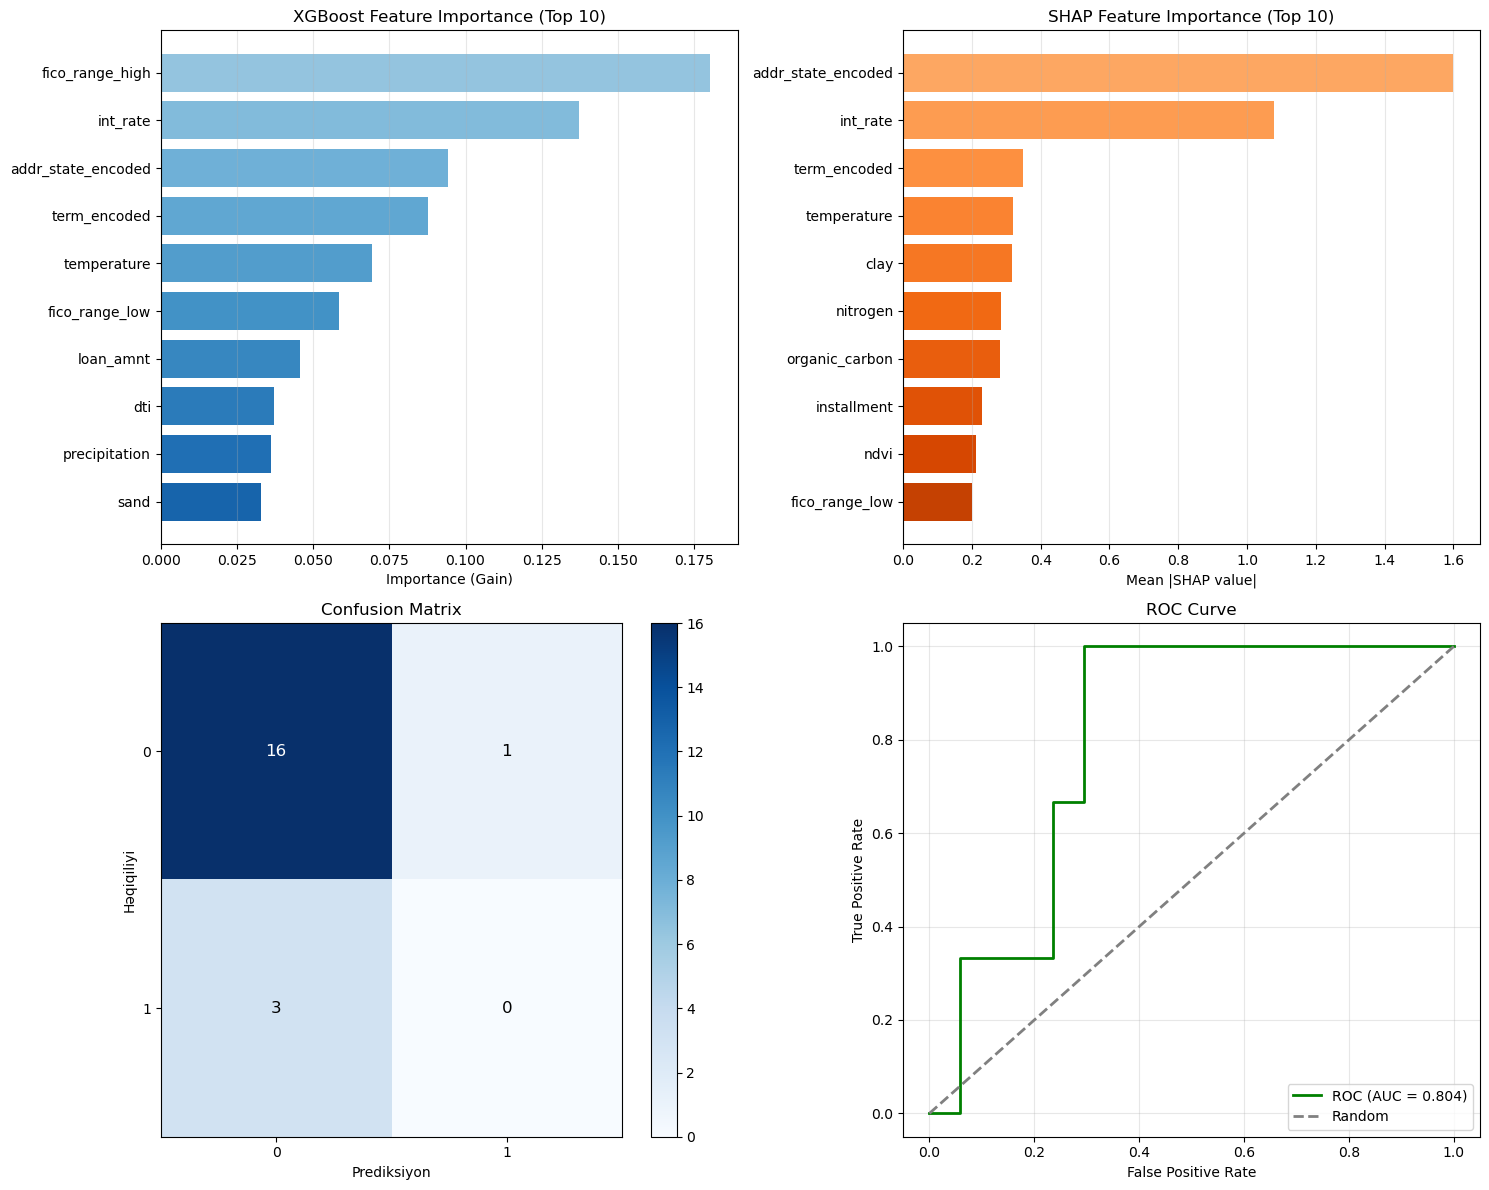

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# 1. XGBoost Feature Importance
ax1 = axes[0, 0]
top_features = feature_importance.head(10)
colors_1 = plt.cm.Blues(np.linspace(0.4, 0.8, len(top_features)))
ax1.barh(range(len(top_features)), top_features['importance'].values, color=colors_1)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features['feature'].values)
ax1.set_xlabel('Importance (Gain)')
ax1.set_title('XGBoost Feature Importance (Top 10)')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. SHAP Feature Importance (əgər mövcuddursa)
ax2 = axes[0, 1]
if 'shap_importance' in locals() and shap_importance is not None:
    top_shap = shap_importance.head(10)
    colors_2 = plt.cm.Oranges(np.linspace(0.4, 0.8, len(top_shap)))
    ax2.barh(range(len(top_shap)), top_shap['mean_abs_shap'].values, color=colors_2)
    ax2.set_yticks(range(len(top_shap)))
    ax2.set_yticklabels(top_shap['feature'].values)
    ax2.set_xlabel('Mean |SHAP value|')
    ax2.set_title('SHAP Feature Importance (Top 10)')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'SHAP\nAnalysis\nNot Available',
             ha='center', va='center', fontsize=14, style='italic', color='gray')
    ax2.set_title('SHAP Feature Importance')
    ax2.axis('off')

# 3. Model Performance: Confusion Matrix
ax3 = axes[1, 0]
im = ax3.imshow(cm, cmap='Blues', aspect='auto')
ax3.set_xlabel('Prediksiyon')
ax3.set_ylabel('Həqiqiliyi')
ax3.set_title('Confusion Matrix')
ax3.set_xticks(range(cm.shape[1]))
ax3.set_yticks(range(cm.shape[0]))
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax3.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
plt.colorbar(im, ax=ax3)

# 4. ROC Curve (əgər mövcuddursa)
ax4 = axes[1, 1]
if roc_auc > 0:
    try:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        ax4.plot(fpr, tpr, color='green', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
        ax4.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')
        ax4.set_xlabel('False Positive Rate')
        ax4.set_ylabel('True Positive Rate')
        ax4.set_title('ROC Curve')
        ax4.legend(loc='lower right')
        ax4.grid(True, alpha=0.3)
    except:
        ax4.text(0.5, 0.5, 'ROC Curve\nNot Available',
                ha='center', va='center', fontsize=14, style='italic', color='gray')
        ax4.axis('off')
        ax4.set_title('ROC Curve')
else:
    ax4.text(0.5, 0.5, 'Sınıf\nImbalansı\n(ROC N/A)',
            ha='center', va='center', fontsize=14, style='italic', color='gray')
    ax4.axis('off')
    ax4.set_title('ROC Curve')

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
